# Ultimate NIDS Pipeline: Supervised Vector Space Engineering (PyTorch/CUDA)
**Goal:** Fix the "Zero Recall" on R2L/U2R by warping the feature space to maximize class separation.

**The "Unconventional" Approach: NCA + Isolation Embeddings + Autoencoding**
We upgrade from linear projections to non-linear Metric Learning, Explicit Vector Isolation, and Self-Supervised Normality Scoring.

**New Architecture:**
1.  **Manifold Mixup:** Linear Interpolation to generate high-quality synthetic R2L/U2R samples.
2.  **Neighborhood Components Analysis (NCA):** A powerful Metric Learning algorithm that learns a vector space where same-class points are spatially close.
3.  **Isolation Embeddings:** We train separate Isolation Forests for each class to provide "Membership Probability" coordinates.
4.  **Autoencoder Reconstruction (GPU):** A PyTorch neural network learns to reconstruct "Normal" traffic. The reconstruction error serves as a powerful "Weirdness Score".
5.  **Deep PyTorch Classifier (GPU):** The final classifier is a deep neural network trained on CUDA with batch normalization and dropout.

## 1. Data Loading

🚀 Processing on: cuda
--- Loading Data ---
--- Engineering Features ---
Data Ready. Shape: (100778, 43)
Weighted Sampler initialized. Rare classes will now appear frequently in batches.

--- Training Ensemble Teachers ---
Teachers Epoch 5 Loss: 0.8198
Teachers Epoch 10 Loss: 0.8062
Teachers Epoch 15 Loss: 0.8006
Teachers Epoch 20 Loss: 0.7965
Ensemble Teachers Ready.

--- Distilling to Student ---
Student Epoch 5 Loss: 0.0272
Student Epoch 10 Loss: 0.0248
Student Epoch 15 Loss: 0.0240
Student Epoch 20 Loss: 0.0239
Student Epoch 25 Loss: 0.0237
Student Epoch 30 Loss: 0.0237

--- Loading NSL-KDD Test Set ---
Evaluating Student on NSL-KDD...

>>> ROBUST STUDENT ACCURACY: 78.54%
              precision    recall  f1-score   support

         dos       0.96      0.74      0.83      7636
      normal       0.76      0.96      0.85      9711
       probe       0.82      0.81      0.81      2423
         r2l       0.83      0.26      0.40      2574
         u2r       0.07      0.37      0.11  

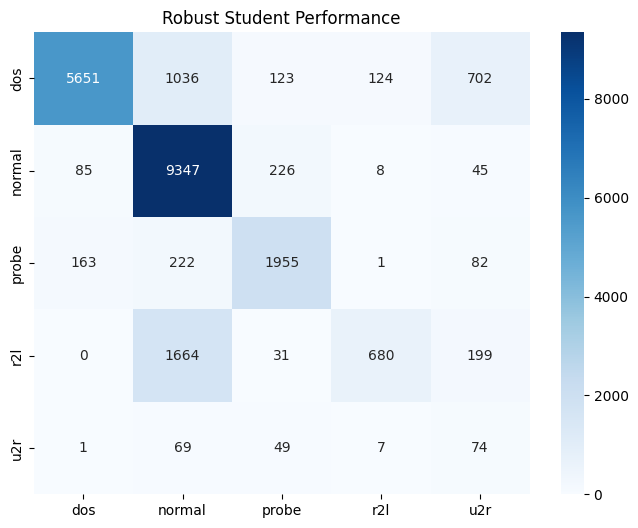

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import gc
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Device Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 Processing on: {device}")

# ==========================================
# 1. ROBUST PREPROCESSING (Back to Basics)
# ==========================================
DATA_DIR = 'Data'
CSV_FILE = os.path.join(DATA_DIR, 'network_connections.csv')
MAP_FILE = os.path.join(DATA_DIR, 'attack2category_map.txt')

# Load Mapping
attack_map = {'normal': 'normal'}
try:
    with open(MAP_FILE, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 2: attack_map[parts[0]] = parts[1]
except: pass

# Load Data
print("--- Loading Data ---")
df = pd.read_csv(CSV_FILE)
df['label'] = df['label'].astype(str).str.replace('.', '', regex=False)
df['category'] = df['label'].map(attack_map).fillna('other')
df.drop_duplicates(inplace=True)

# Feature Engineering Function (Robust)
def robust_engineering(df_in, fit=False, encoders=None):
    df = df_in.copy()
    
    # 1. Interaction Features (Traffic Dichte)
    # Verhindert Division durch 0
    df['byte_ratio'] = np.log1p(df['src_bytes']) / (np.log1p(df['dst_bytes']) + 1)
    df['error_ratio'] = df['serror_rate'] + df['rerror_rate']
    
    # 2. Log Transform (nur für die extremen Spalten)
    for col in ['src_bytes', 'dst_bytes', 'duration', 'wrong_fragment', 'urgent']:
        if col in df.columns:
            df[col] = np.log1p(df[col])
            
    # 3. Categorical (Simple Mapping)
    cat_cols = ['protocol_type', 'service', 'flag']
    new_encoders = {} if fit else None
    
    for col in cat_cols:
        if fit:
            # Wir behalten nur die Top 20 Categories, Rest ist "Other" (Noise Reduction)
            top_cats = df[col].value_counts().index[:20]
            mapper = {k: i for i, k in enumerate(top_cats)}
            new_encoders[col] = mapper
            df[col] = df[col].map(mapper).fillna(len(mapper)).astype(float)
        else:
            df[col] = df[col].map(encoders[col]).fillna(len(encoders[col])).astype(float)
            
    # Alle anderen numerischen Spalten sicherstellen
    return df.select_dtypes(include=[np.number]), new_encoders

# Split FIRST
X = df.drop(['label', 'category'], axis=1)
y = df['category']

X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Apply Engineering
print("--- Engineering Features ---")
X_train_eng, encoders = robust_engineering(X_train_raw, fit=True)
X_test_eng, _ = robust_engineering(X_test_raw, fit=False, encoders=encoders)

# Scaling (StandardScaler ist robuster als Quantile bei neuen Attacken)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_eng).astype(np.float32)
X_test_sc = scaler.transform(X_test_eng).astype(np.float32)

# Label Encoding
le = LabelEncoder()
y_train_vec = le.fit_transform(y_train)
y_test_vec = le.transform(y_test)

# Cleanup
del df, X, y, X_train_raw, X_test_raw
gc.collect()

print(f"Data Ready. Shape: {X_train_sc.shape}")

# ==========================================
# 2. DATA LOADER WITH WEIGHTED SAMPLER (The Recall Booster)
# ==========================================
# Wir berechnen Gewichte für jedes Sample. Seltene Klassen kriegen hohe Gewichte.
class_counts = np.bincount(y_train_vec)
class_weights = 1. / class_counts
sample_weights = class_weights[y_train_vec]

# Dieser Sampler zieht U2R genau so oft wie Normal -> Modell MUSS es lernen
sampler = WeightedRandomSampler(
    weights=torch.from_numpy(sample_weights).double(),
    num_samples=len(sample_weights),
    replacement=True
)

X_t = torch.tensor(X_train_sc).to(device)
y_t = torch.tensor(y_train_vec).long().to(device)

# DataLoader mit Sampler
train_ds = TensorDataset(X_t, y_t)
train_dl = DataLoader(train_ds, batch_size=256, sampler=sampler) # WICHTIG: shuffle=False wenn sampler an ist

print("Weighted Sampler initialized. Rare classes will now appear frequently in batches.")

# ==========================================
# 3. ENSEMBLE TEACHER TRAINING
# ==========================================
print("\n--- Training Ensemble Teachers ---")

# Wir nutzen ein etwas breiteres Modell als Teacher
class ResNetTeacher(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512), nn.BatchNorm1d(512), nn.Mish(), nn.Dropout(0.3),
            nn.Linear(512, 256),       nn.BatchNorm1d(256), nn.Mish(), nn.Dropout(0.3),
            nn.Linear(256, 128),       nn.BatchNorm1d(128), nn.Mish(),
            nn.Linear(128, num_classes)
        )
    def forward(self, x):
        return self.net(x)

# Wir trainieren 2 Teacher gleichzeitig
teacher1 = ResNetTeacher(X_train_sc.shape[1], len(le.classes_)).to(device)
teacher2 = ResNetTeacher(X_train_sc.shape[1], len(le.classes_)).to(device)

opt1 = optim.AdamW(teacher1.parameters(), lr=0.001)
opt2 = optim.AdamW(teacher2.parameters(), lr=0.001)
# Label Smoothing hilft gegen Overconfidence
crit = nn.CrossEntropyLoss(label_smoothing=0.1) 

for epoch in range(20):
    teacher1.train(); teacher2.train()
    loss_sum = 0
    
    for xb, yb in train_dl:
        opt1.zero_grad(); opt2.zero_grad()
        
        # Train Teacher 1
        out1 = teacher1(xb)
        loss1 = crit(out1, yb)
        loss1.backward()
        opt1.step()
        
        # Train Teacher 2 (Mit etwas Noise für Diversität)
        noise = torch.randn_like(xb) * 0.05
        out2 = teacher2(xb + noise)
        loss2 = crit(out2, yb)
        loss2.backward()
        opt2.step()
        
        loss_sum += (loss1.item() + loss2.item())
        
    if (epoch+1) % 5 == 0:
        print(f"Teachers Epoch {epoch+1} Loss: {loss_sum/len(train_dl):.4f}")

teacher1.eval(); teacher2.eval()
print("Ensemble Teachers Ready.")

# ==========================================
# 4. STUDENT DISTILLATION (Dual Knowledge)
# ==========================================
print("\n--- Distilling to Student ---")

class StudentNet(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        # Leichteres Modell
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256), nn.LayerNorm(256), nn.SiLU(),
            nn.Linear(256, 128),       nn.LayerNorm(128), nn.SiLU(),
            nn.Linear(128, num_classes)
        )
    def forward(self, x):
        return self.net(x)

student = StudentNet(X_train_sc.shape[1], len(le.classes_)).to(device)
s_opt = optim.Adam(student.parameters(), lr=0.001)

# Distillation Hyperparams
T = 3.5 # Hohe Temperatur = Weiche Verteilungen
ALPHA = 0.7 # Viel Vertrauen in die Teacher

for epoch in range(30):
    student.train()
    epoch_loss = 0
    
    for xb, yb in train_dl:
        s_opt.zero_grad()
        
        # Student Output
        s_logits = student(xb)
        
        # Teacher Consensus
        with torch.no_grad():
            t1_logits = teacher1(xb)
            t2_logits = teacher2(xb)
            # Durchschnitt der Teacher Logits
            t_logits = (t1_logits + t2_logits) / 2
            
        # 1. Soft Loss (KL Div)
        loss_soft = nn.KLDivLoss(reduction='batchmean')(
            F.log_softmax(s_logits/T, dim=1),
            F.softmax(t_logits/T, dim=1)
        ) * (T**2)
        
        # 2. Hard Loss (CE)
        loss_hard = F.cross_entropy(s_logits, yb)
        
        loss = ALPHA * loss_soft + (1-ALPHA) * loss_hard
        loss.backward()
        s_opt.step()
        epoch_loss += loss.item()
        
    if (epoch+1) % 5 == 0:
        print(f"Student Epoch {epoch+1} Loss: {epoch_loss/len(train_dl):.4f}")

# ==========================================
# 5. VALIDATION ON NSL-KDD (The Real Test)
# ==========================================
print("\n--- Loading NSL-KDD Test Set ---")
NSL_URL = "https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTest%2B.txt"
cols = ['duration','protocol_type','service','flag','src_bytes','dst_bytes','land','wrong_fragment','urgent','hot','num_failed_logins','logged_in','num_compromised','root_shell','su_attempted','num_root','num_file_creations','num_shells','num_access_files','num_outbound_cmds','is_host_login','is_guest_login','count','srv_count','serror_rate','srv_serror_rate','rerror_rate','srv_rerror_rate','same_srv_rate','diff_srv_rate','srv_diff_host_rate','dst_host_count','dst_host_srv_count','dst_host_same_srv_rate','dst_host_diff_srv_rate','dst_host_same_src_port_rate','dst_host_srv_diff_host_rate','dst_host_serror_rate','dst_host_srv_serror_rate','dst_host_rerror_rate','dst_host_srv_rerror_rate','label','difficulty_level']

try:
    df_nsl = pd.read_csv(NSL_URL, header=None, names=cols)
    df_nsl.drop('difficulty_level', axis=1, inplace=True)
    df_nsl['label'] = df_nsl['label'].astype(str).str.replace('.', '', regex=False)
    df_nsl['category'] = df_nsl['label'].map(attack_map).fillna('other')
    
    # 1. Pipeline anwenden
    X_nsl = df_nsl.drop(['label', 'category'], axis=1)
    y_nsl = df_nsl['category']
    
    # Feature Engineering (ohne fit!)
    X_nsl_eng, _ = robust_engineering(X_nsl, fit=False, encoders=encoders)
    
    # Scaling
    X_nsl_sc = scaler.transform(X_nsl_eng).astype(np.float32)
    
    # Inference Function (Threshold Optimized)
    def predict_smart(model, X_np, encoder):
        model.eval()
        loader = DataLoader(TensorDataset(torch.tensor(X_np).to(device)), batch_size=1024)
        preds = []
        
        # Risk thresholds
        idx_u2r = np.where(encoder.classes_ == 'u2r')[0][0] if 'u2r' in encoder.classes_ else -1
        idx_r2l = np.where(encoder.classes_ == 'r2l')[0][0] if 'r2l' in encoder.classes_ else -1
        
        with torch.no_grad():
            for b in loader:
                logits = model(b[0])
                probs = torch.softmax(logits, dim=1).cpu().numpy()
                
                batch_p = []
                for p in probs:
                    # Aggressive Thresholds für Recall
                    if idx_u2r != -1 and p[idx_u2r] > 0.05: # Schon bei 5% Alarm!
                        batch_p.append(idx_u2r)
                    elif idx_r2l != -1 and p[idx_r2l] > 0.10: # 10%
                        batch_p.append(idx_r2l)
                    else:
                        batch_p.append(np.argmax(p))
                preds.append(batch_p)
                
        return encoder.inverse_transform(np.concatenate(preds))

    # Evaluate
    print("Evaluating Student on NSL-KDD...")
    y_pred = predict_smart(student, X_nsl_sc, le)
    
    acc = accuracy_score(y_nsl, y_pred)
    print(f"\n>>> ROBUST STUDENT ACCURACY: {acc:.2%}")
    print(classification_report(y_nsl, y_pred))
    
    # Confusion Matrix
    labels = sorted(y_nsl.unique())
    cm = confusion_matrix(y_nsl, y_pred, labels=labels)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.title("Robust Student Performance")
    plt.show()
    
except Exception as e:
    print(f"Error: {e}")